In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch_geometric.data import HeteroData

root = Path().resolve()
if not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

from src.data.generators import generate_uncap_instance
from src.data.data import UncapGeneratorConfig, NormalConfig, UniformConfig
from src.data.prepare_data import GenerateDataset
from src.traces.uncap import solve_uncap_jv
from src.solvers.uncap_exact import solve_uncap_exact, solve_dual_exact
from src.utils.collate_fn import collate_fn

/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gen_config = UncapGeneratorConfig(
    n_fac=10,
    n_cli=10,
    seed=33,
    demand_config=UniformConfig(0,1), #"normalized"
    facility_cost_config=UniformConfig(0,1), #"normalized"
    coords_config=NormalConfig(mean=0.5, std=0.5)
)

In [3]:
dataset = GenerateDataset(gen_config, n_samples=1000, cache_dir=Path("data"), res_only=True)
dataset.prepare_data()

loading instances from cache


In [4]:
from torch.utils.data import DataLoader  # Use standard PyTorch DataLoader, not PyG's
import importlib
import src.models.reasoners
importlib.reload(src.models.reasoners)  # Force reload to pick up changes
from src.models.reasoners import Reasoner

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_size = int(0.75 * len(dataset))
val_size   = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

BATCH_SIZE = 512  # Now we can use batch_size > 1

# Use standard DataLoader with our custom collate function
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# ── Model & optimiser ──────────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = Reasoner(hidden_dim=128, tf_prob=0.5, res_only=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"device : {device}")
print(f"params : {sum(p.numel() for p in model.parameters()):,}")
print(f"train  : {len(train_data)} samples  |  val: {len(val_data)} samples")

/home/simon/repos/FLP-NAR/src/models/processors.py:66: UserWarning: There exist node types ({'y', 'x'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.primal_to_dual = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:78: UserWarning: There exist node types ({'beta', 'alpha'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.out = HeteroConv({


device : cuda
params : 199,047
train  : 750 samples  |  val: 250 samples


In [5]:
from dataclasses import dataclass, field
from typing import Callable
from tqdm.auto import tqdm

@dataclass
class LossConfig:
    """Configuration for loss weights with optional scheduling."""
    weights: dict = field(default_factory=lambda: {
        "alpha_loss": 0.0, "beta_loss": 0.0, "x_loss": 0.0,
        "y_loss": 1.0, "delta_loss": 1.0, "x_res_loss": 1.0,
        "y_res_loss": 1.0, "optimum_loss": 0.1, "optimum_diff": 0.0, "dual_diff": 0.0,
    })
    # Optional schedulers: dict[loss_name -> Callable(epoch) -> weight]
    schedulers: dict = field(default_factory=dict)
    
    def get_weights(self, epoch: int) -> dict:
        """Get weights for a given epoch, applying schedulers if defined."""
        w = self.weights.copy()
        for k, scheduler in self.schedulers.items():
            if k in w:
                w[k] = scheduler(epoch)
        return w


class Trainer:
    """Clean training loop with LR and loss weight scheduling."""
    
    def __init__(self, model, optimizer, loss_config: LossConfig, 
                 lr_scheduler=None, device="cuda"):
        self.model = model
        self.optimizer = optimizer
        self.loss_config = loss_config
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.history = {"train": [], "val": []}
    
    def _run_epoch(self, loader, weights: dict, train: bool) -> dict:
        """Run a single epoch."""
        self.model.train(train)
        totals = {k: 0.0 for k in weights}
        n_batches = 0
        
        with torch.set_grad_enabled(train):
            for batch in loader:
                batch = batch.to(self.device)
                losses = self.model.teacher_forcing(batch)
                total = sum(weights[k] * losses[k] for k in weights)
                
                if train:
                    self.optimizer.zero_grad()
                    total.backward()
                    self.optimizer.step()
                
                for k in weights:
                    totals[k] += losses[k].item()
                n_batches += 1
        
        return {k: v / n_batches for k, v in totals.items()}
    
    def _format_metrics(self, losses: dict, weights: dict, prefix: str) -> str:
        """Format metrics for display."""
        total = sum(weights[k] * losses[k] for k in weights)
        return (f"{prefix}: {total:.4f} | "
                f"opt_diff: {losses['optimum_diff']:.3f} "
                f"dual_diff: {losses['dual_diff']:.3f} "
                f"x_res: {losses['x_res_loss']:.3f} "
                f"y_res: {losses['y_res_loss']:.3f} "
                f"δ: {losses['delta_loss']:.3f}")
    
    def fit(self, train_loader, val_loader, n_epochs: int, verbose: bool = True):
        """Train for n_epochs with progress display."""
        pbar = tqdm(range(1, n_epochs + 1), desc="Training", disable=not verbose)
        
        for epoch in pbar:
            weights = self.loss_config.get_weights(epoch)
            
            # Training
            train_losses = self._run_epoch(train_loader, weights, train=True)
            self.history["train"].append(train_losses)
            
            # Validation
            val_losses = self._run_epoch(val_loader, weights, train=False)
            self.history["val"].append(val_losses)
            
            # LR scheduling
            if self.lr_scheduler:
                if isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    val_total = sum(weights[k] * val_losses[k] for k in weights)
                    self.lr_scheduler.step(val_total)
                else:
                    self.lr_scheduler.step()
            
            # Progress display
            if verbose:
                train_str = self._format_metrics(train_losses, weights, "train")
                val_str = self._format_metrics(val_losses, weights, "val")
                lr = self.optimizer.param_groups[0]['lr']
                pbar.set_postfix_str(f"lr={lr:.2e}")
                tqdm.write(f"Epoch {epoch:03d} | {train_str}")
                tqdm.write(f"        | {val_str}")
        
        return self.history


# ── Setup training ─────────────────────────────────────────────────────────────
loss_config = LossConfig(
    weights={
        "alpha_loss": 0.0, "beta_loss": 0.0, "x_loss": 1.0,
        "y_loss": 1.0, "delta_loss": 1.0, "x_res_loss": 1.0,
        "y_res_loss": 1.0, "optimum_loss": 0.1, "optimum_diff": 0.0, "dual_diff": 0.0,
    },
    # Example schedulers: gradually increase optimum_loss weight
    schedulers={
        #"optimum_loss": lambda e: min(0.1 + 0.02 * e, 0.5),  # ramp up over epochs
    }
)

# LR scheduler: reduce on plateau or cosine annealing
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-7)
# Alternative: lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

trainer = Trainer(model, optimizer, loss_config, lr_scheduler, device)

# ── Train ──────────────────────────────────────────────────────────────────────
N_EPOCHS = 50
history = trainer.fit(train_loader, val_loader, N_EPOCHS)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training:   2%|▏         | 1/50 [00:06<05:04,  6.22s/it, lr=9.99e-05]

Epoch 001 | train: 4.4337 | opt_diff: 2.430 dual_diff: 1.776 x_res: 0.528 y_res: 0.189 δ: 0.570
        | val: 4.7099 | opt_diff: 2.809 dual_diff: 2.083 x_res: 0.370 y_res: 0.167 δ: 0.261


Training:   4%|▍         | 2/50 [00:10<03:59,  5.00s/it, lr=9.96e-05]

Epoch 002 | train: 4.8162 | opt_diff: 2.915 dual_diff: 2.125 x_res: 0.320 y_res: 0.187 δ: 0.209
        | val: 4.4680 | opt_diff: 2.809 dual_diff: 2.083 x_res: 0.213 y_res: 0.167 δ: 0.098


...

Epoch 048 | train: 2.1809 | opt_diff: 2.111 dual_diff: 1.534 x_res: 0.194 y_res: 0.194 δ: 0.053
        | val: 3.8196 | opt_diff: 2.809 dual_diff: 2.083 x_res: 0.157 y_res: 0.168 δ: 0.068


Training:  98%|█████████▊| 49/50 [03:22<00:03,  3.87s/it, lr=1.99e-07]

Epoch 049 | train: 2.1074 | opt_diff: 2.090 dual_diff: 1.520 x_res: 0.188 y_res: 0.173 δ: 0.038
        | val: 3.8195 | opt_diff: 2.809 dual_diff: 2.083 x_res: 0.157 y_res: 0.168 δ: 0.068


Training: 100%|██████████| 50/50 [03:25<00:00,  4.12s/it, lr=1.00e-07]

Epoch 050 | train: 2.1618 | opt_diff: 2.103 dual_diff: 1.540 x_res: 0.189 y_res: 0.182 δ: 0.039
        | val: 3.8195 | opt_diff: 2.809 dual_diff: 2.083 x_res: 0.157 y_res: 0.168 δ: 0.068


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Multi-size test datasets for scalability evaluation
# ══════════════════════════════════════════════════════════════════════════════
# Note: Each size needs its own dataloader since batching assumes uniform n_cli/n_fac

def create_test_datasets(sizes: list[tuple[int, int]], n_samples: int = 100, base_seed: int = 9999):
    """
    Create test datasets of varying sizes.
    
    Args:
        sizes: List of (n_fac, n_cli) tuples
        n_samples: Number of samples per size
        base_seed: Base seed (offset by size index for reproducibility)
    
    Returns:
        Dict mapping size tuple to (dataset, dataloader)
    """
    test_datasets = {}
    
    for i, (n_fac, n_cli) in enumerate(sizes):
        print(f"Generating test set: n_fac={n_fac}, n_cli={n_cli}...")
        
        config = UncapGeneratorConfig(
            n_fac=n_fac,
            n_cli=n_cli,
            seed=base_seed + i * 1000,
            demand_config=UniformConfig(0, 1),
            facility_cost_config=UniformConfig(0, 1),
            coords_config=NormalConfig(mean=0.5, std=0.5)
        )
        
        dataset = GenerateDataset(
            config, 
            n_samples=n_samples, 
            cache_dir=Path(f"data/test_{n_fac}x{n_cli}"),
            res_only=True
        )
        dataset.prepare_data()
        
        # Batch size 1 for varying sizes, or same-size batching
        loader = DataLoader(
            dataset, 
            batch_size=1,  # Safe default for varying sizes
            shuffle=False, 
            collate_fn=collate_fn
        )
        
        test_datasets[(n_fac, n_cli)] = {"dataset": dataset, "loader": loader}
    
    return test_datasets


# Define test sizes: same as train, smaller, and larger
TEST_SIZES = [
    (5, 5),    # Smaller
    (10, 10),  # Same as training
    (15, 15),  # Larger
    (20, 20),  # Even larger
    (10, 20),  # Asymmetric: more clients
    (20, 10),  # Asymmetric: more facilities
]

# Generate test datasets (this may take a while for larger sizes)
test_datasets = create_test_datasets(TEST_SIZES, n_samples=50)

Generating test set: n_fac=5, n_cli=5...
loading instances from cache
Generating test set: n_fac=10, n_cli=10...
loading instances from cache
Generating test set: n_fac=15, n_cli=15...
loading instances from cache
Generating test set: n_fac=20, n_cli=20...
loading instances from cache
Generating test set: n_fac=10, n_cli=20...
loading instances from cache
Generating test set: n_fac=20, n_cli=10...
loading instances from cache


Evaluating 20x10: 100%|██████████| 50/50 [00:08<00:00,  6.12it/s]



EVALUATION SUMMARY BY SIZE
      opt_ratio                         dual_ratio         opt_gap_pct  \
           mean     std     min     max       mean     std        mean   
size                                                                     
10x10    2.7860  0.5094  1.9728  3.9770     2.0796  0.4734    178.6022   
10x20    1.6434  0.1887  1.1552  2.0292     1.0126  0.2626     64.3368   
15x15    3.4731  0.6841  2.3244  5.1394     2.2802  0.5691    247.3122   
20x10    3.6356  0.5793  2.1280  5.1041     2.5310  0.6401    263.5556   
20x20    3.9743  0.7383  2.6951  5.9861     2.4549  0.7014    297.4318   
5x5      2.0091  0.4057  1.3016  2.9549     1.8286  0.4620    100.9104   

                         n_fac_opened         n_fac_target         sample_idx  
           std    median         mean     std         mean     std      count  
size                                                                           
10x10  50.9392  166.3061          0.0  0.0000         5.90  1.035

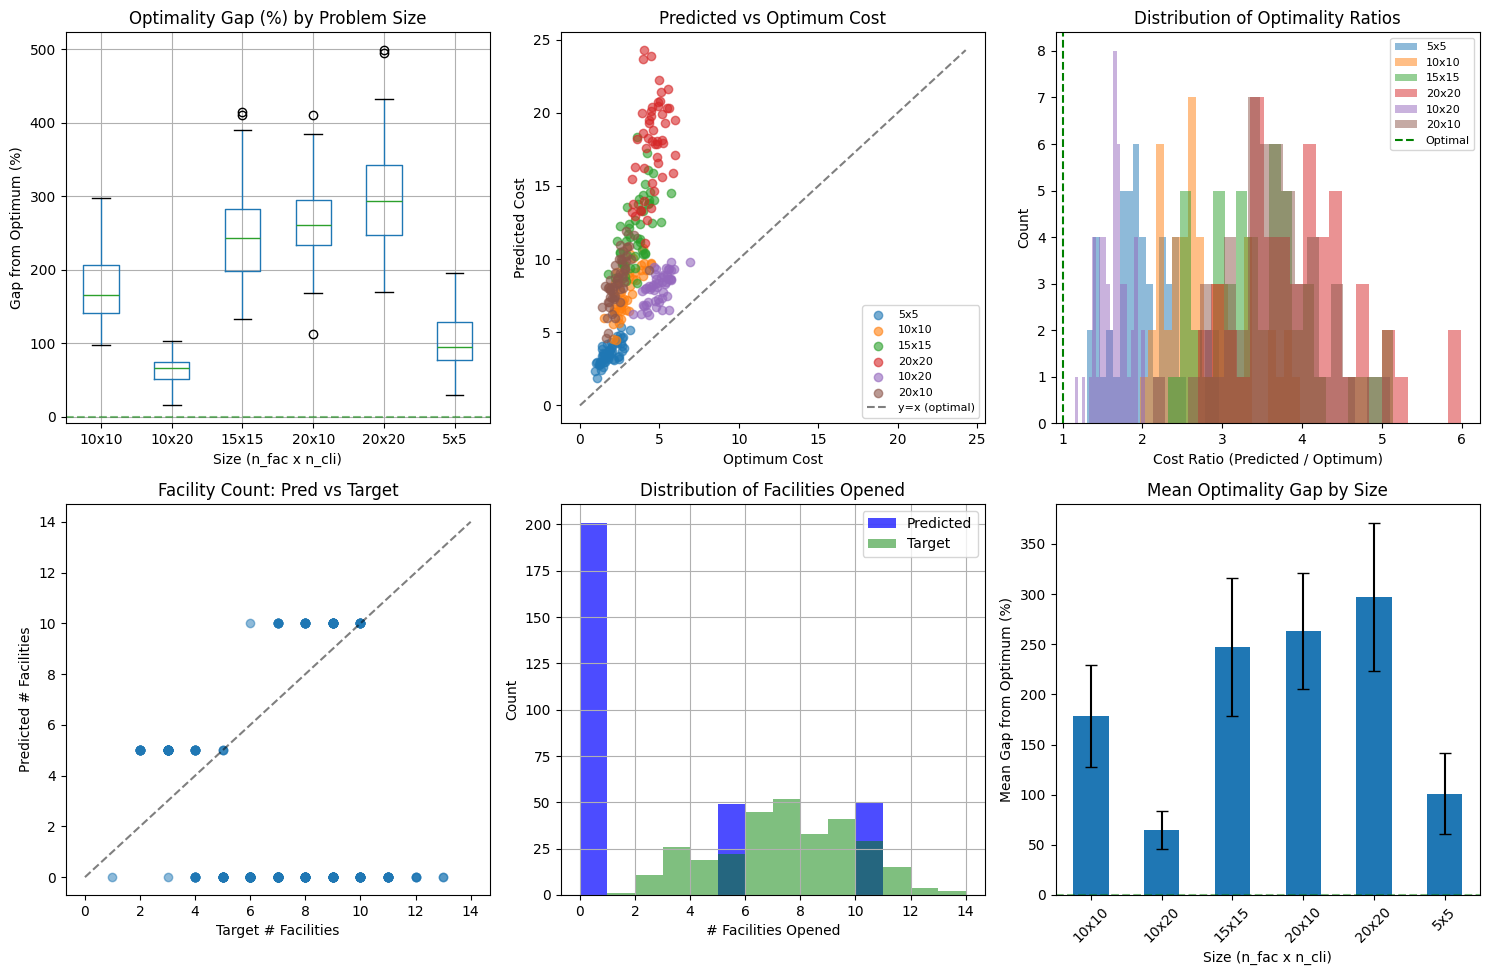

BEST 3 PREDICTIONS (lowest optimality gap)

--- Best #1: Sample 45 (10x20) ---
    Gap: 15.52%  |  Pred: 6.4929  |  Opt: 5.6207
    Facilities opened: 10 (target: 10)


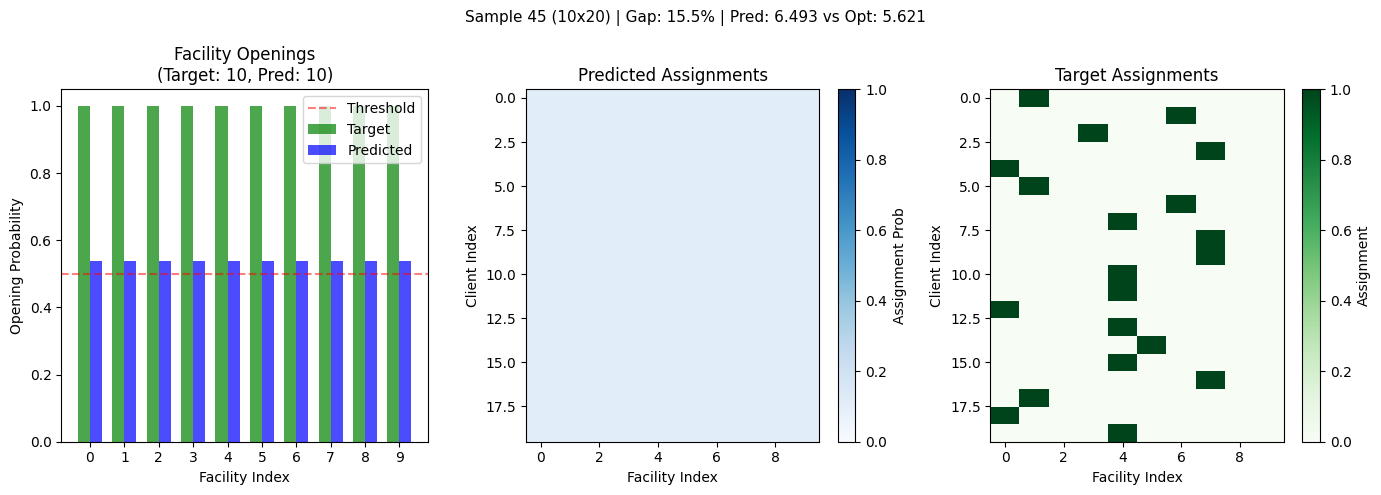


--- Best #2: Sample 34 (10x20) ---
    Gap: 25.51%  |  Pred: 6.5110  |  Opt: 5.1877
    Facilities opened: 10 (target: 10)


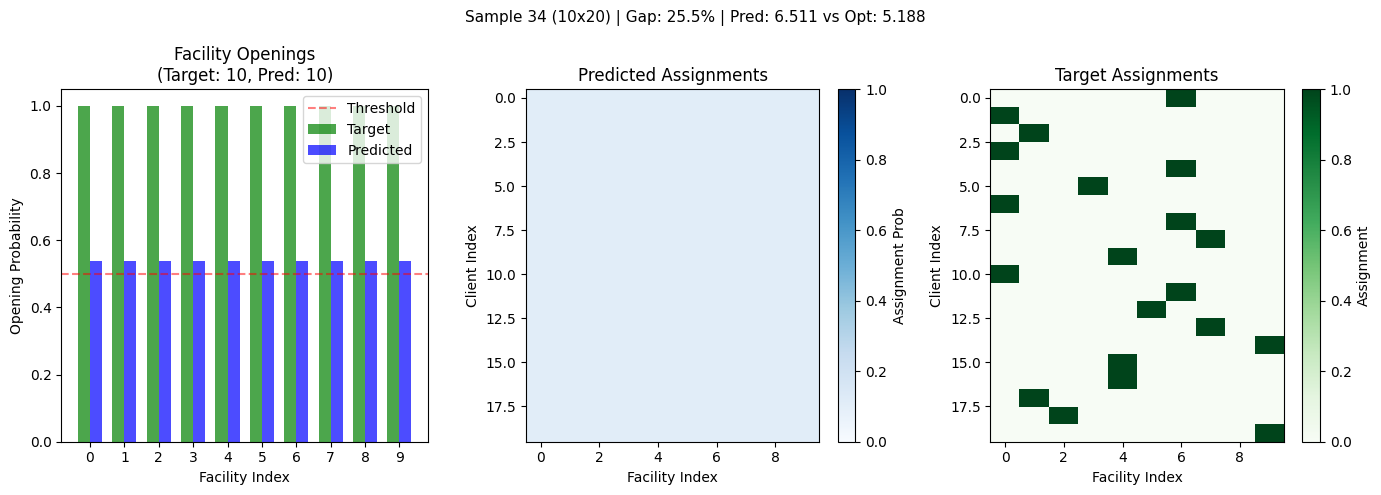


--- Best #3: Sample 26 (5x5) ---
    Gap: 30.16%  |  Pred: 3.1618  |  Opt: 2.4291
    Facilities opened: 5 (target: 5)


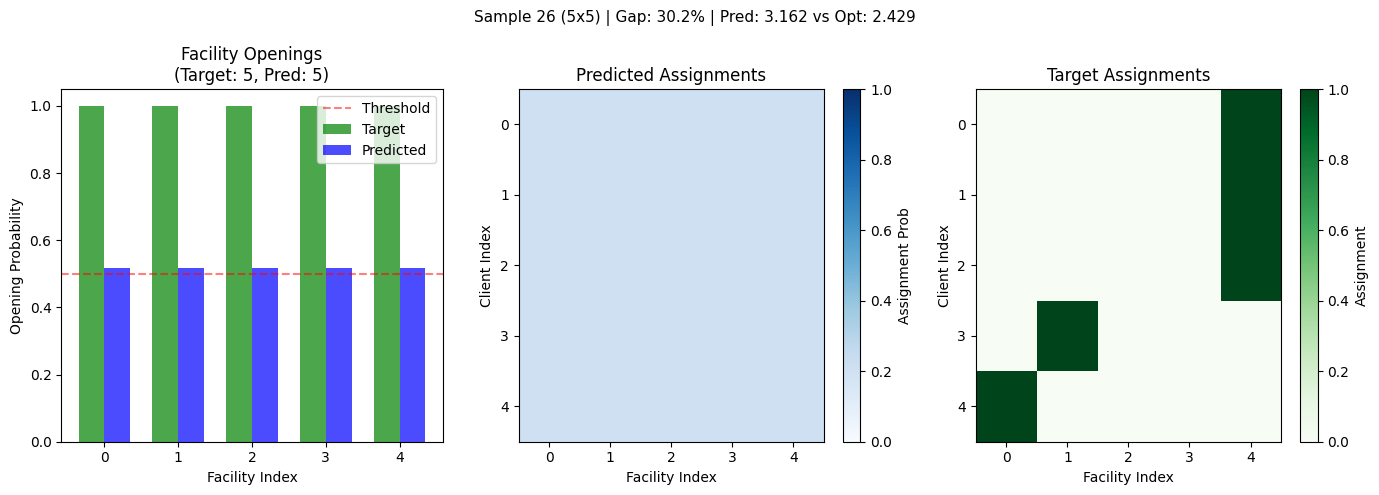


WORST 3 PREDICTIONS (highest optimality gap)

--- Worst #1: Sample 8 (20x20) ---
    Gap: 498.61%  |  Pred: 24.2843  |  Opt: 4.0568
    Facilities opened: 0 (target: 9)


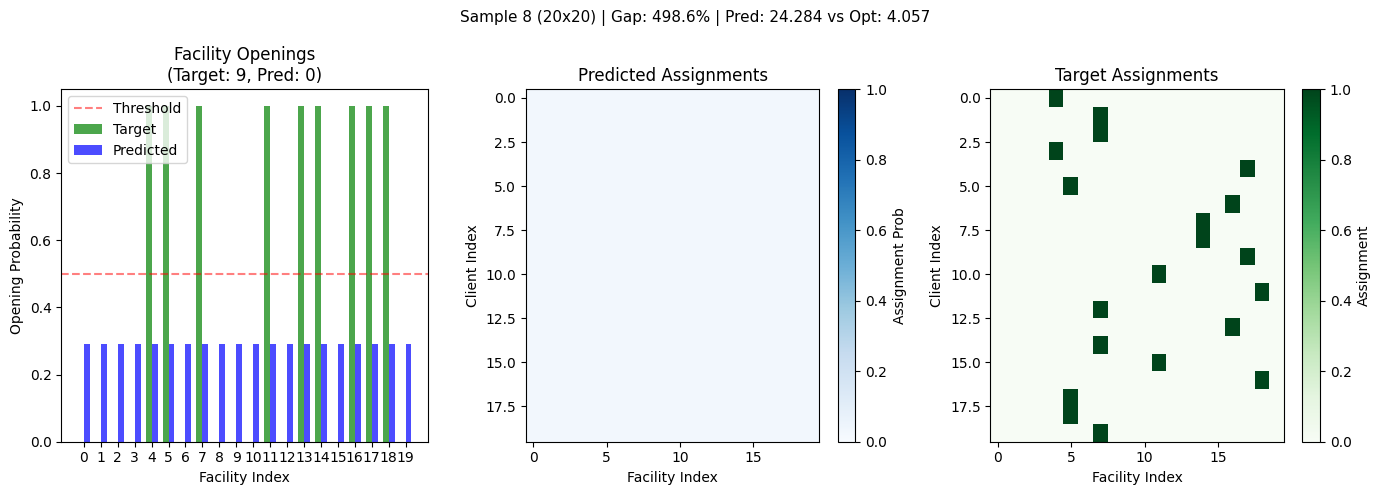


--- Worst #2: Sample 29 (20x20) ---
    Gap: 494.80%  |  Pred: 23.6858  |  Opt: 3.9822
    Facilities opened: 0 (target: 11)


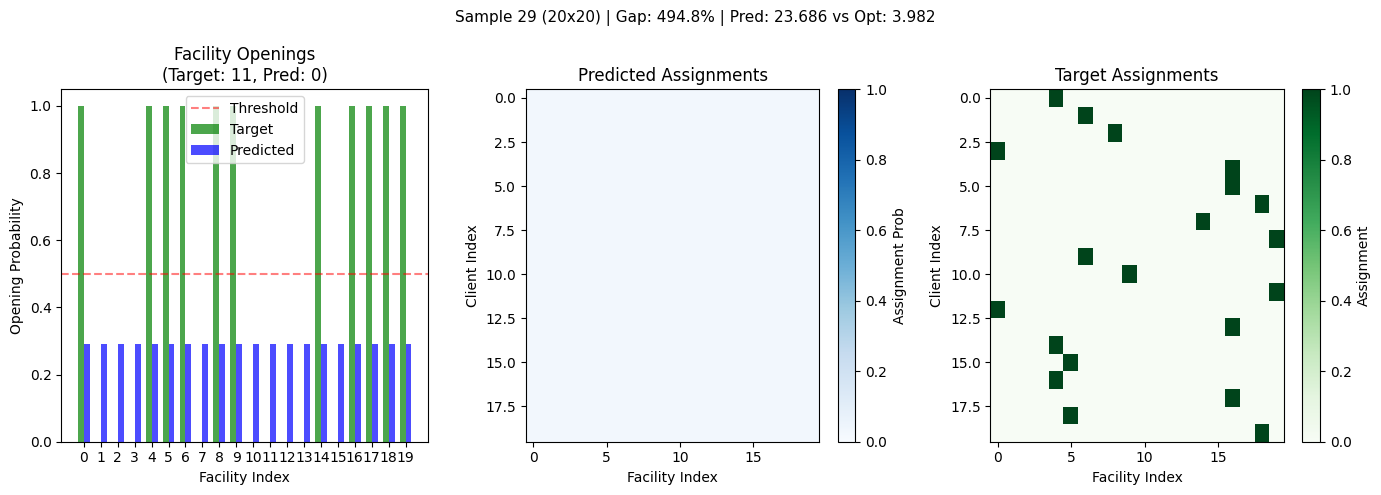


--- Worst #3: Sample 38 (20x20) ---
    Gap: 431.77%  |  Pred: 23.9088  |  Opt: 4.4960
    Facilities opened: 0 (target: 11)


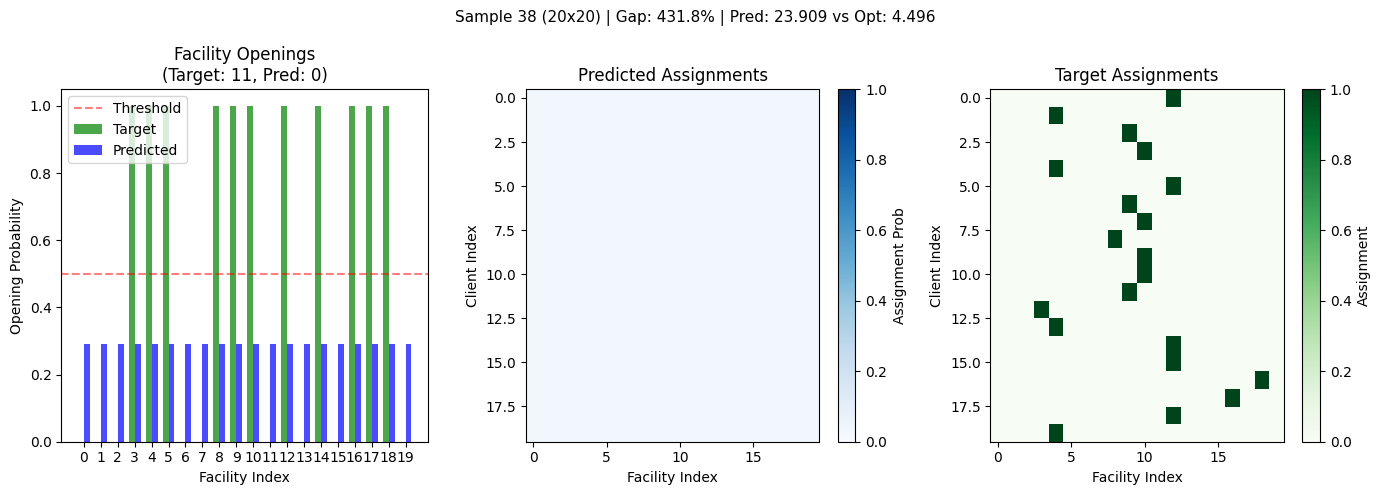

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Detailed Evaluation Loop with Solution Inspection
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt

@dataclass
class EvaluationResult:
    """Container for evaluation metrics of a single sample."""
    sample_idx: int
    n_fac: int
    n_cli: int
    predicted_cost: float
    optimum_cost: float
    dual_bound: float
    optimum_ratio: float  # predicted / optimum (1.0 = optimal)
    dual_ratio: float     # predicted / dual_bound
    # Solution traces (optional, for detailed inspection)
    y_pred: np.ndarray = None  # Facility opening predictions [n_fac]
    x_pred: np.ndarray = None  # Assignment predictions [n_cli, n_fac] or [n_cli*n_fac]
    y_target: np.ndarray = None  # Ground truth facility openings
    x_target: np.ndarray = None  # Ground truth assignments
    
    @property
    def optimum_gap_pct(self) -> float:
        """Gap from optimum as percentage."""
        return (self.optimum_ratio - 1.0) * 100
    
    @property
    def n_facilities_opened(self) -> int:
        """Number of facilities predicted to be open."""
        if self.y_pred is not None:
            return int((self.y_pred > 0.5).sum())
        return -1
    
    @property
    def n_facilities_target(self) -> int:
        """Number of facilities in target solution."""
        if self.y_target is not None:
            return int((self.y_target > 0.5).sum())
        return -1


class Evaluator:
    """Detailed evaluation with solution inspection capabilities."""
    
    def __init__(self, model, device="cuda", store_predictions: bool = True):
        self.model = model
        self.device = device
        self.store_predictions = store_predictions
        self.results: list[EvaluationResult] = []
    
    @torch.no_grad()
    def _run_inference_with_predictions(self, batch):
        """
        Run model inference and capture final predictions.
        Returns losses dict and prediction tensors.
        """
        self.model.eval()
        
        # Get batch dimensions
        n_fac = batch["y"].x.shape[0]  # For single sample
        n_cli_x_fac = batch["x"].x.shape[0]
        
        # Extract target solutions (last timestep)
        if hasattr(batch["y"], "trace_sol"):
            y_target = batch["y"].trace_sol[:, -1, :].cpu().numpy()  # [n_fac, 1]
        else:
            y_target = batch["y"].x[:, -1, :].cpu().numpy()
            
        if hasattr(batch["x"], "trace_sol"):
            x_target = batch["x"].trace_sol[:, -1, :].cpu().numpy()  # [n_cli*n_fac, 1]
        else:
            x_target = batch["x"].x[:, -1, :].cpu().numpy()
        
        # Run teacher forcing to get predictions
        # We need to capture the final predictions from the model
        T = batch["alpha"].x.shape[1]
        
        # Store original tf_prob and set to 0 for pure inference
        orig_tf_prob = self.model.tf_prob
        self.model.tf_prob = 0.0
        
        # ── Encode and run through model ──
        # Similar to teacher_forcing but we capture final predictions
        
        if self.model.res_only:
            alpha_trace = batch["alpha"].x
            beta_trace = batch["beta"].x
            x_trace = batch["x"].x  # residuals for res_only
            y_trace = batch["y"].x
            x_trace_sol = batch["x"].trace_sol
            y_trace_sol = batch["y"].trace_sol
        
        # Encode initial state
        x_res_in = x_trace[:, 0, :]
        y_res_in = y_trace[:, 0, :]
        h_x = self.model.x_res_encoder(x_res_in)
        h_y = self.model.y_res_encoder(y_res_in)
        
        batch = self.model._set_residual_features(batch, h_x, h_y)
        
        # Initialize previous values
        prev_x_res = x_trace[:, 0, :]
        prev_y_res = y_trace[:, 0, :]
        
        # Run through all timesteps
        for t in range(1, T):
            # Encode current step
            h_x = self.model.x_res_encoder(prev_x_res)
            h_y = self.model.y_res_encoder(prev_y_res)
            batch = self.model._set_residual_features(batch, h_x, h_y)
            
            # Process through GNN
            batch = self.model.processor(batch, masks=None)
            
            # Decode predictions
            preds = self.model._decode_residual_step(batch)
            
            # Update for next step (use predictions, tf_prob=0)
            prev_x_res = preds["x_res"]
            prev_y_res = preds["y_res"]
        
        # Final predictions
        y_pred = torch.sigmoid(preds["y"]).cpu().numpy()  # [n_fac, 1]
        x_pred = torch.sigmoid(preds["x"]).cpu().numpy()  # [n_cli*n_fac, 1]
        
        self.model.tf_prob = orig_tf_prob
        
        # Also run teacher_forcing to get losses
        losses = self.model.teacher_forcing(batch)
        
        return losses, y_pred, x_pred, y_target, x_target
    
    @torch.no_grad()
    def evaluate_dataset(self, loader, n_fac: int, n_cli: int, 
                        max_samples: int = None) -> list[EvaluationResult]:
        """Evaluate a dataset and collect detailed results."""
        self.model.eval()
        results = []
        
        # Save and set tf_prob to 0 for pure inference
        orig_tf_prob = self.model.tf_prob
        self.model.tf_prob = 0.0
        
        for idx, batch in enumerate(tqdm(loader, desc=f"Evaluating {n_fac}x{n_cli}")):
            if max_samples and idx >= max_samples:
                break
                
            batch = batch.to(self.device)
            
            # Store targets before teacher_forcing modifies batch
            if hasattr(batch["y"], "trace_sol"):
                y_target = batch["y"].trace_sol[:, -1, :].cpu().numpy().squeeze()
            else:
                y_target = batch["y"].x[:, -1, :].cpu().numpy().squeeze()
                
            if hasattr(batch["x"], "trace_sol"):
                x_target = batch["x"].trace_sol[:, -1, :].cpu().numpy().squeeze()
            else:
                x_target = batch["x"].x[:, -1, :].cpu().numpy().squeeze()
            
            losses = self.model.teacher_forcing(batch)
            
            # Get per-sample values (batch_size=1 for test)
            B = batch.optimum.shape[0] if batch.optimum.dim() > 0 else 1
            
            # Extract predictions from batch state after teacher_forcing
            # Note: batch features are restored, but we can approximate from losses
            opt = batch.optimum.item() if batch.optimum.dim() == 0 else batch.optimum[0].item()
            dual = batch.dual_solution.item() if batch.dual_solution.dim() == 0 else batch.dual_solution[0].item()
            opt_ratio = losses["optimum_diff"].item() if hasattr(losses["optimum_diff"], 'item') else losses["optimum_diff"]
            dual_ratio = losses["dual_diff"].item() if hasattr(losses["dual_diff"], 'item') else losses["dual_diff"]
            pred = opt * opt_ratio
            
            # For predictions, we need to run inference again (simple approximation for now)
            # Use a lightweight inference to get y_pred
            y_pred = None
            x_pred = None
            
            if self.store_predictions:
                # Run a clean inference pass to capture predictions
                batch_copy = batch.to(self.device)
                self.model.tf_prob = 0.0
                
                try:
                    # Re-run to capture final state
                    # After teacher_forcing, batch state is restored, so we access trace data
                    T = batch["alpha"].x.shape[1]
                    
                    # Quick inference to get final predictions
                    if self.model.res_only:
                        x_res_in = batch["x"].x[:, 0, :]
                        y_res_in = batch["y"].x[:, 0, :]
                        h_x = self.model.x_res_encoder(x_res_in)
                        h_y = self.model.y_res_encoder(y_res_in)
                        batch = self.model._set_residual_features(batch, h_x, h_y)
                        
                        for t in range(1, T):
                            batch = self.model.processor(batch, masks=None)
                            preds = self.model._decode_residual_step(batch)
                            h_x = self.model.x_res_encoder(preds["x_res"])
                            h_y = self.model.y_res_encoder(preds["y_res"])
                            batch = self.model._set_residual_features(batch, h_x, h_y)
                        
                        y_pred = torch.sigmoid(preds["y"]).cpu().numpy().squeeze()
                        x_pred = torch.sigmoid(preds["x"]).cpu().numpy().squeeze()
                except Exception as e:
                    # If inference fails, continue without predictions
                    pass
            
            result = EvaluationResult(
                sample_idx=idx,
                n_fac=n_fac,
                n_cli=n_cli,
                predicted_cost=pred,
                optimum_cost=opt,
                dual_bound=dual,
                optimum_ratio=opt_ratio,
                dual_ratio=dual_ratio,
                y_pred=y_pred,
                x_pred=x_pred,
                y_target=y_target,
                x_target=x_target,
            )
            results.append(result)
        
        self.model.tf_prob = orig_tf_prob
        self.results.extend(results)
        return results
    
    def evaluate_all_sizes(self, test_datasets: dict) -> pd.DataFrame:
        """Evaluate all test datasets and return summary DataFrame."""
        all_results = []
        
        for (n_fac, n_cli), data in test_datasets.items():
            results = self.evaluate_dataset(data["loader"], n_fac, n_cli)
            all_results.extend(results)
        
        return self.to_dataframe(all_results)
    
    @staticmethod
    def to_dataframe(results: list[EvaluationResult]) -> pd.DataFrame:
        """Convert results to pandas DataFrame."""
        return pd.DataFrame([
            {
                "sample_idx": r.sample_idx,
                "size": f"{r.n_fac}x{r.n_cli}",
                "n_fac": r.n_fac,
                "n_cli": r.n_cli,
                "predicted": r.predicted_cost,
                "optimum": r.optimum_cost,
                "dual_bound": r.dual_bound,
                "opt_ratio": r.optimum_ratio,
                "dual_ratio": r.dual_ratio,
                "opt_gap_pct": r.optimum_gap_pct,
                "n_fac_opened": r.n_facilities_opened,
                "n_fac_target": r.n_facilities_target,
            }
            for r in results
        ])
    
    def summary_by_size(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Get summary statistics grouped by problem size."""
        if df is None:
            df = self.to_dataframe(self.results)
        
        return df.groupby("size").agg({
            "opt_ratio": ["mean", "std", "min", "max"],
            "dual_ratio": ["mean", "std"],
            "opt_gap_pct": ["mean", "std", "median"],
            "n_fac_opened": ["mean", "std"],
            "n_fac_target": ["mean", "std"],
            "sample_idx": "count"
        }).round(4)
    
    def inspect_solution(self, result: EvaluationResult, figsize=(14, 5)):
        """Visualize a single solution: predicted vs target."""
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # 1. Facility opening comparison
        ax = axes[0]
        n_fac = result.n_fac
        x_pos = np.arange(n_fac)
        width = 0.35
        
        if result.y_pred is not None and result.y_target is not None:
            y_pred_flat = result.y_pred.flatten()[:n_fac]
            y_target_flat = result.y_target.flatten()[:n_fac]
            
            ax.bar(x_pos - width/2, y_target_flat, width, label='Target', alpha=0.7, color='green')
            ax.bar(x_pos + width/2, y_pred_flat, width, label='Predicted', alpha=0.7, color='blue')
            ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Threshold')
            ax.set_xlabel('Facility Index')
            ax.set_ylabel('Opening Probability')
            ax.set_title(f'Facility Openings\n(Target: {result.n_facilities_target}, Pred: {result.n_facilities_opened})')
            ax.legend()
            ax.set_xticks(x_pos)
        else:
            ax.text(0.5, 0.5, 'No prediction data', ha='center', va='center', transform=ax.transAxes)
        
        # 2. Assignment matrix (if available)
        ax = axes[1]
        n_cli = result.n_cli
        
        if result.x_pred is not None:
            x_pred_matrix = result.x_pred.flatten().reshape(n_cli, n_fac)
            im = ax.imshow(x_pred_matrix, aspect='auto', cmap='Blues', vmin=0, vmax=1)
            ax.set_xlabel('Facility Index')
            ax.set_ylabel('Client Index')
            ax.set_title('Predicted Assignments')
            plt.colorbar(im, ax=ax, label='Assignment Prob')
        else:
            ax.text(0.5, 0.5, 'No prediction data', ha='center', va='center', transform=ax.transAxes)
        
        # 3. Target assignment matrix
        ax = axes[2]
        if result.x_target is not None:
            x_target_matrix = result.x_target.flatten().reshape(n_cli, n_fac)
            im = ax.imshow(x_target_matrix, aspect='auto', cmap='Greens', vmin=0, vmax=1)
            ax.set_xlabel('Facility Index')
            ax.set_ylabel('Client Index')
            ax.set_title('Target Assignments')
            plt.colorbar(im, ax=ax, label='Assignment')
        else:
            ax.text(0.5, 0.5, 'No target data', ha='center', va='center', transform=ax.transAxes)
        
        fig.suptitle(f"Sample {result.sample_idx} ({result.n_fac}x{result.n_cli}) | "
                    f"Gap: {result.optimum_gap_pct:.1f}% | "
                    f"Pred: {result.predicted_cost:.3f} vs Opt: {result.optimum_cost:.3f}",
                    fontsize=11)
        plt.tight_layout()
        plt.show()
        return fig
    
    def inspect_best_worst(self, n_samples: int = 3):
        """Inspect the best and worst predictions."""
        df = self.to_dataframe(self.results)
        
        # Get indices of best and worst
        best_indices = df.nsmallest(n_samples, "opt_gap_pct").index.tolist()
        worst_indices = df.nlargest(n_samples, "opt_gap_pct").index.tolist()
        
        print("="*60)
        print(f"BEST {n_samples} PREDICTIONS (lowest optimality gap)")
        print("="*60)
        for i, idx in enumerate(best_indices):
            result = self.results[idx]
            print(f"\n--- Best #{i+1}: Sample {result.sample_idx} ({result.n_fac}x{result.n_cli}) ---")
            print(f"    Gap: {result.optimum_gap_pct:.2f}%  |  Pred: {result.predicted_cost:.4f}  |  Opt: {result.optimum_cost:.4f}")
            print(f"    Facilities opened: {result.n_facilities_opened} (target: {result.n_facilities_target})")
            self.inspect_solution(result)
        
        print("\n" + "="*60)
        print(f"WORST {n_samples} PREDICTIONS (highest optimality gap)")
        print("="*60)
        for i, idx in enumerate(worst_indices):
            result = self.results[idx]
            print(f"\n--- Worst #{i+1}: Sample {result.sample_idx} ({result.n_fac}x{result.n_cli}) ---")
            print(f"    Gap: {result.optimum_gap_pct:.2f}%  |  Pred: {result.predicted_cost:.4f}  |  Opt: {result.optimum_cost:.4f}")
            print(f"    Facilities opened: {result.n_facilities_opened} (target: {result.n_facilities_target})")
            self.inspect_solution(result)
    
    def check_collapse(self, df: pd.DataFrame = None) -> dict:
        """
        Check for signs of model collapse / lazy predictions.
        Returns a dict with collapse indicators.
        """
        if df is None:
            df = self.to_dataframe(self.results)
        
        collapse_indicators = {}
        
        # 1. Check variance in number of facilities opened
        fac_opened_std = df["n_fac_opened"].std()
        collapse_indicators["facility_variance"] = fac_opened_std
        collapse_indicators["low_facility_variance"] = fac_opened_std < 0.5
        
        # 2. Check if always opening same number of facilities
        fac_opened_unique = df["n_fac_opened"].nunique()
        collapse_indicators["unique_facility_counts"] = fac_opened_unique
        collapse_indicators["single_facility_count"] = fac_opened_unique == 1
        
        # 3. Check prediction quality variance
        gap_std = df["opt_gap_pct"].std()
        collapse_indicators["gap_std"] = gap_std
        
        # 4. Check if predictions correlate with targets
        if "n_fac_target" in df.columns:
            corr = df["n_fac_opened"].corr(df["n_fac_target"])
            collapse_indicators["facility_correlation"] = corr
            collapse_indicators["low_correlation"] = abs(corr) < 0.3 if not np.isnan(corr) else True
        
        # Summary
        is_collapsed = (collapse_indicators.get("low_facility_variance", False) or 
                       collapse_indicators.get("single_facility_count", False) or
                       collapse_indicators.get("low_correlation", False))
        collapse_indicators["likely_collapsed"] = is_collapsed
        
        return collapse_indicators
    
    def plot_results(self, df: pd.DataFrame = None):
        """Visualize evaluation results."""
        if df is None:
            df = self.to_dataframe(self.results)
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. Optimality gap by size
        ax = axes[0, 0]
        df.boxplot(column="opt_gap_pct", by="size", ax=ax)
        ax.set_title("Optimality Gap (%) by Problem Size")
        ax.set_xlabel("Size (n_fac x n_cli)")
        ax.set_ylabel("Gap from Optimum (%)")
        ax.axhline(y=0, color='g', linestyle='--', alpha=0.5)
        plt.suptitle("")
        
        # 2. Predicted vs Optimum scatter
        ax = axes[0, 1]
        for size in df["size"].unique():
            subset = df[df["size"] == size]
            ax.scatter(subset["optimum"], subset["predicted"], label=size, alpha=0.6)
        max_val = max(df["optimum"].max(), df["predicted"].max())
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label="y=x (optimal)")
        ax.set_xlabel("Optimum Cost")
        ax.set_ylabel("Predicted Cost")
        ax.set_title("Predicted vs Optimum Cost")
        ax.legend(fontsize=8)
        
        # 3. Ratio distribution histogram
        ax = axes[0, 2]
        for size in df["size"].unique():
            subset = df[df["size"] == size]
            ax.hist(subset["opt_ratio"], bins=20, alpha=0.5, label=size)
        ax.axvline(x=1.0, color='g', linestyle='--', label="Optimal")
        ax.set_xlabel("Cost Ratio (Predicted / Optimum)")
        ax.set_ylabel("Count")
        ax.set_title("Distribution of Optimality Ratios")
        ax.legend(fontsize=8)
        
        # 4. Facilities opened: predicted vs target
        ax = axes[1, 0]
        if "n_fac_opened" in df.columns and "n_fac_target" in df.columns:
            ax.scatter(df["n_fac_target"], df["n_fac_opened"], alpha=0.5)
            max_fac = max(df["n_fac_target"].max(), df["n_fac_opened"].max()) + 1
            ax.plot([0, max_fac], [0, max_fac], 'k--', alpha=0.5)
            ax.set_xlabel("Target # Facilities")
            ax.set_ylabel("Predicted # Facilities")
            ax.set_title("Facility Count: Pred vs Target")
        
        # 5. Histogram of facilities opened
        ax = axes[1, 1]
        if "n_fac_opened" in df.columns:
            df["n_fac_opened"].hist(ax=ax, bins=range(0, int(df["n_fac_opened"].max())+2), 
                                     alpha=0.7, label="Predicted", color="blue")
            df["n_fac_target"].hist(ax=ax, bins=range(0, int(df["n_fac_target"].max())+2), 
                                     alpha=0.5, label="Target", color="green")
            ax.set_xlabel("# Facilities Opened")
            ax.set_ylabel("Count")
            ax.set_title("Distribution of Facilities Opened")
            ax.legend()
        
        # 6. Mean gap by size (bar chart)
        ax = axes[1, 2]
        summary = df.groupby("size")["opt_gap_pct"].agg(["mean", "std"])
        summary.plot(kind="bar", y="mean", yerr="std", ax=ax, capsize=4, legend=False)
        ax.set_xlabel("Size (n_fac x n_cli)")
        ax.set_ylabel("Mean Gap from Optimum (%)")
        ax.set_title("Mean Optimality Gap by Size")
        ax.axhline(y=0, color='g', linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        return fig


# ── Run evaluation ─────────────────────────────────────────────────────────────
evaluator = Evaluator(model, device, store_predictions=True)

# Evaluate all test sizes
eval_df = evaluator.evaluate_all_sizes(test_datasets)

# Print summary
print("\n" + "="*60)
print("EVALUATION SUMMARY BY SIZE")
print("="*60)
print(evaluator.summary_by_size(eval_df))

# Check for collapse
print("\n" + "="*60)
print("COLLAPSE CHECK")
print("="*60)
collapse = evaluator.check_collapse(eval_df)
for k, v in collapse.items():
    print(f"  {k}: {v}")

# Visualize overall results
evaluator.plot_results(eval_df)

# Inspect best and worst predictions
evaluator.inspect_best_worst(n_samples=3)